In [1]:
import csv
import json
import glob
import os
import numpy as np

import pandas as pd


In [2]:
TRACE_FOLDER = "real_yt_data_capacity_traffic/"
OUTPUT_JSON = "scenario_20_ue_4K.json"

suffix = "share-small-BiAtLSTM_task=max_alpha=0.01_seq=82_pred=1_delay=30"

filenames = {
    "preds": f"pred_max_{suffix}.npy",
    "oracle": f"true_oracle_max_{suffix}.npy",
    "true_traj": f"true_future_{suffix}.npy",
    "lengths": f"future_lengths_{suffix}.npy",
    "boundaries": f"window_boundaries_{suffix}.npy"
}

# 2. LOAD DATA

boundaries = np.load(filenames["boundaries"]) # Session start/end indices [NumSessions, 2]
boundaries_size = boundaries[:,1]-boundaries[:,0]
selected_sessions = np.where(boundaries_size == 15)[0]



In [3]:
sessions_4k = [118,121,125,127,135,136,161,181] ### manually selected
sessions_480p = [102,103, 112,119, 123,128,133,148] ### manually selected

all_sessions_4k =[118,121,125,127,181,187,245,281,283,29,323,408,418,422,440,445,458,50,66,95]


selected_quality = all_sessions_4k

In [34]:
ues = []
csv_files = sorted(glob.glob(os.path.join(TRACE_FOLDER, "*.csv")))

In [35]:
selected_ues = []
for csv_file in csv_files:
    ue_id = csv_file.split("/")[-1].split(".")[0].split("_")[3]
    ue_id = int(ue_id)
    if ue_id in selected_quality:
        selected_ues.append(csv_file)


In [36]:
csv_file

'real_yt_data_capacity_traffic/YT_data_session_95_capacity_traffic.csv'

In [37]:
selected_ues

['real_yt_data_capacity_traffic/YT_data_session_118_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_121_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_125_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_127_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_181_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_187_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_245_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_281_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_283_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_29_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_323_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_408_capacity_traffic.csv',
 'real_yt_data_capacity_traffic/YT_data_session_418_capacity_traffic.csv',
 'real_yt_data_capacity_tr

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

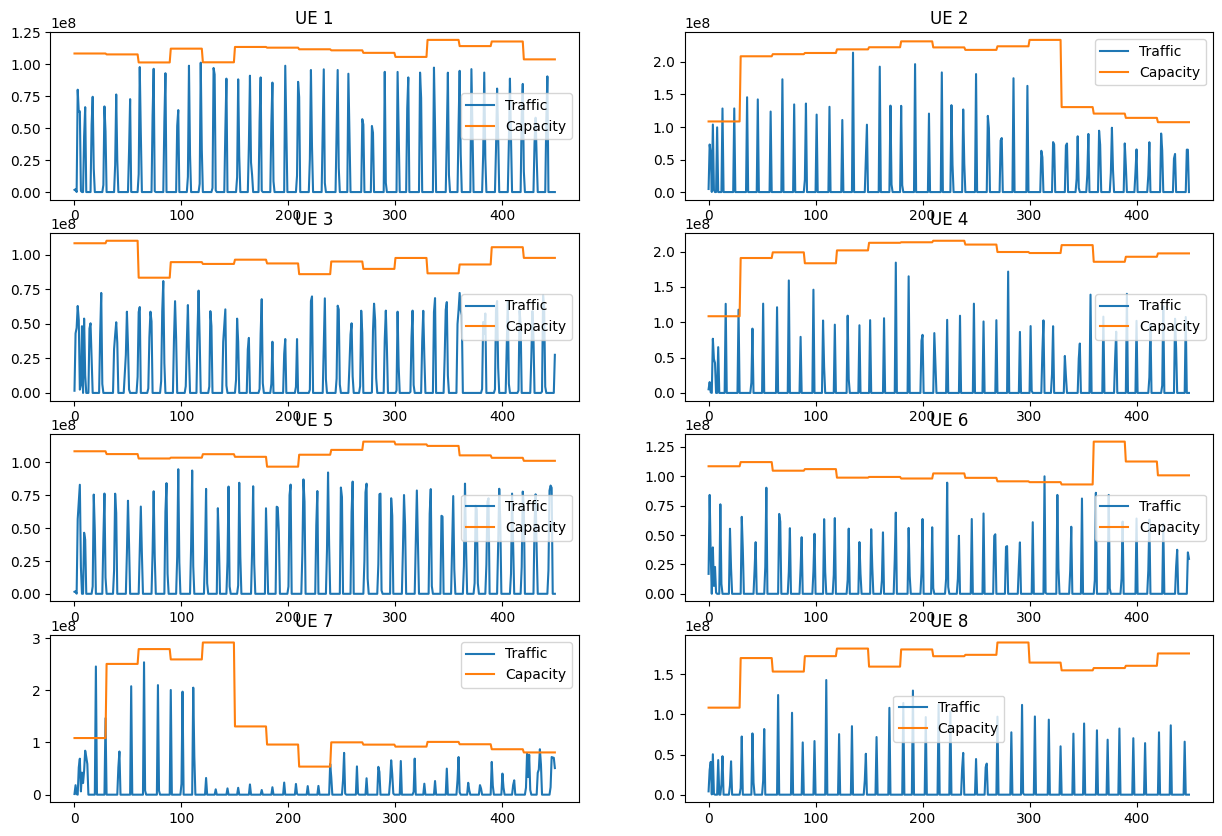

In [29]:
fig,ax = plt.subplots(4,2, figsize=(15,10))
for i, csv_file in enumerate(selected_ues):
    df = pd.read_csv(csv_file)
    ax[i//2, i%2].plot(df.traffic, label="Traffic")
    ax[i//2, i%2].plot(df.GFBR, label="Capacity")
    ax[i//2, i%2].set_title(f"UE {i+1}")
    ax[i//2, i%2].legend()


In [ ]:

###### ALL GBR ######
ues = []
# csv_files = sorted(glob.glob(os.path.join(TRACE_FOLDER, "session*.csv")))

for i, file in enumerate(selected_ues, start=1):
    print(f"Processing {file} for UE {i}...")

    traffic = []
    gfbr = []

    with open(file, newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            t = float(row["traffic"])
            g = float(row["GFBR"])
            # if t <=1e4:
            #     t=5e5  # avoid zero time for the first sample
            # if g <=1e4:
            #     g=5e5  # avoid zero GFBR for the first sample
            
            # if t > g:
            #     g=t  # cap GFBR to traffic if it exceeds it

            traffic.append(t)      # already in bps
            gfbr.append(g)       # or traffic again

    ue = {
        "id": i,
        "fiveqi": "GBR_CONV_VIDEO",
        "traffic_bps": traffic,
        "gfbr_bps": gfbr
    }

    ues.append(ue)
     # Process only the first UE for testing
    
config = {
    "trace_interval": 1,
    "scheduler": "DPP",
    "time_samples": len(traffic),
    "ues": ues
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(config, f, indent=2)

print(f"Generated {OUTPUT_JSON} with {len(ues)} UEs.")

Processing real_yt_data_capacity_traffic/YT_data_session_118_capacity_traffic.csv for UE 1...
Processing real_yt_data_capacity_traffic/YT_data_session_121_capacity_traffic.csv for UE 2...
Processing real_yt_data_capacity_traffic/YT_data_session_125_capacity_traffic.csv for UE 3...
Processing real_yt_data_capacity_traffic/YT_data_session_127_capacity_traffic.csv for UE 4...
Processing real_yt_data_capacity_traffic/YT_data_session_181_capacity_traffic.csv for UE 5...
Processing real_yt_data_capacity_traffic/YT_data_session_187_capacity_traffic.csv for UE 6...
Processing real_yt_data_capacity_traffic/YT_data_session_245_capacity_traffic.csv for UE 7...
Processing real_yt_data_capacity_traffic/YT_data_session_281_capacity_traffic.csv for UE 8...
Processing real_yt_data_capacity_traffic/YT_data_session_283_capacity_traffic.csv for UE 9...
Processing real_yt_data_capacity_traffic/YT_data_session_29_capacity_traffic.csv for UE 10...
Processing real_yt_data_capacity_traffic/YT_data_session_323

In [ ]:
###### 4ue GBR, 4ue NGBR ######
ues = []
# csv_files = sorted(glob.glob(os.path.join(TRACE_FOLDER, "session*.csv")))

fiveqi= ['GBR_CONV_VIDEO','NGBR_LOW_LAT_EMBB']
for i, file in enumerate(selected_ues, start=1):
    print(f"Processing {file} for UE {i}...")

    traffic = []
    gfbr = []

    if i >= 5:
        q = fiveqi[0]

        with open(file, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                t = float(row["traffic"])
                g = float(row["GFBR"])
                # if t <=1e4:
                #     t=5e5  # avoid zero time for the first sample
                # if g <=1e4:
                #     g=5e5  # avoid zero GFBR for the first sample
                
                # if t > g:
                #     g=t  # cap GFBR to traffic if it exceeds it

                traffic.append(t)      # already in bps
                gfbr.append(g)       # or traffic again

    
    else:
        q = fiveqi[1]
        with open(file, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                t = float(row["traffic"])
                g = float(row["GFBR"])
                # if t <=1e4:
                #     t=5e5  # avoid zero time for the first sample
                # if g <=1e4:
                #     g=5e5  # avoid zero GFBR for the first sample
                
                # if t > g:
                #     g=t  # cap GFBR to traffic if it exceeds it

                traffic.append(t)      # already in bps
                gfbr.append(0)       # or traffic again

    ue = {
        "id": i,
        "fiveqi": q,
        "traffic_bps": traffic,
        "gfbr_bps": gfbr
    }

    ues.append(ue)
     # Process only the first UE for testing
    
config = {
    "trace_interval": 1,
    "scheduler": "DPP",
    "time_samples": len(traffic),
    "ues": ues
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(config, f, indent=2)

print(f"Generated {OUTPUT_JSON} with {len(ues)} UEs.")

Processing real_yt_data_capacity_traffic/YT_data_session_118_capacity_traffic.csv for UE 1...
Processing real_yt_data_capacity_traffic/YT_data_session_121_capacity_traffic.csv for UE 2...
Processing real_yt_data_capacity_traffic/YT_data_session_125_capacity_traffic.csv for UE 3...
Processing real_yt_data_capacity_traffic/YT_data_session_127_capacity_traffic.csv for UE 4...
Processing real_yt_data_capacity_traffic/YT_data_session_181_capacity_traffic.csv for UE 5...
Processing real_yt_data_capacity_traffic/YT_data_session_187_capacity_traffic.csv for UE 6...
Processing real_yt_data_capacity_traffic/YT_data_session_245_capacity_traffic.csv for UE 7...
Processing real_yt_data_capacity_traffic/YT_data_session_281_capacity_traffic.csv for UE 8...
Processing real_yt_data_capacity_traffic/YT_data_session_283_capacity_traffic.csv for UE 9...
Processing real_yt_data_capacity_traffic/YT_data_session_29_capacity_traffic.csv for UE 10...
Processing real_yt_data_capacity_traffic/YT_data_session_323

In [ ]:
import csv
import json
import os
import pandas as pd

# Make sure these match your notebook variables
TRACE_FOLDER = "real_yt_data_capacity_traffic/"
all_sessions_4k = [118, 121, 125, 127, 181, 187, 245, 281, 283, 29, 323, 408, 418, 422, 440, 445, 458, 50, 66, 95]

# Build the exact file paths based on your 20 sessions
selected_ues = [os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv") for session_id in all_sessions_4k]
fiveqi= ['GBR_CONV_VIDEO','NGBR_LOW_LAT_EMBB']

# Loop from N=1 to N=10 to create the different scenarios (1v1, 2v2, ... 10v10)
for n in range(1, 11):
    ues = []
    
    # We need 2*N UEs for this scenario (N for GBR, N for Non-GBR)
    current_scenario_files = selected_ues[:2*n]
    
    for i, csv_file in enumerate(current_scenario_files):
        traffic = []
        gfbr = []
        
        # Read the CSV to get the traffic (assuming 'Capacity' or 'Traffic' column logic from your notebook)
        df = pd.read_csv(csv_file)
        
        # Determine if this UE is GBR or Non-GBR
        # The first 'n' UEs will be GBR, the next 'n' will be Non-GBR
        is_gbr = (i < n)
        
        fiveqi = 'GBR_CONV_VIDEO' if is_gbr else 'NGBR_LOW_LAT_EMBB'  # 5QI 4 = GBR (e.g. Video), 5QI 9 = Non-GBR (Default)
        
        # Loop through the rows to build the traffic and GFBR arrays
        for index, row in df.iterrows():
            # Adjust the column name 'Traffic_bps' if yours is named differently (e.g., 'Capacity')
            # t = int(row['Traffic_bps']) if 'Traffic_bps' in df.columns else int(row.iloc[1])
            # g = int(row['GFBR_bps']) if 'GFBR_bps' in df.columns else int(row.iloc[2])
            t = float(row["traffic"])
            g = float(row["GFBR"])
            
            
            traffic.append(t)
            
            if is_gbr:
                gfbr.append(g)  # GBR UEs request their traffic as GFBR
            else:
                gfbr.append(0)  # Non-GBR UEs have 0 GFBR
                
        ue = {
            "session_id": all_sessions_4k[i],  # Add session ID for reference
            "id": i + 1,        # UE IDs starting from 1
            "fiveqi": fiveqi,
            "traffic_bps": traffic,
            "gfbr_bps": gfbr

        }
        
        ues.append(ue)
        
    # Build the configuration dictionary
    config = {
        "trace_interval": 1,
        "scheduler": "DPP",
        "time_samples": len(traffic), # Assuming all UEs have the same length
        "ues": ues
    }
    
    # Save to a specific JSON file for this scenario
    output_filename = f"scenario_{n}gbr_{n}nongbr_4K.json"
    with open(output_filename, "w") as f:
        json.dump(config, f, indent=2)
        
    print(f"Generated {output_filename} with {len(ues)} UEs ({n} GBR, {n} Non-GBR).")

Generated scenario_1gbr_1nongbr_4K.json with 2 UEs (1 GBR, 1 Non-GBR).
Generated scenario_2gbr_2nongbr_4K.json with 4 UEs (2 GBR, 2 Non-GBR).
Generated scenario_3gbr_3nongbr_4K.json with 6 UEs (3 GBR, 3 Non-GBR).
Generated scenario_4gbr_4nongbr_4K.json with 8 UEs (4 GBR, 4 Non-GBR).
Generated scenario_5gbr_5nongbr_4K.json with 10 UEs (5 GBR, 5 Non-GBR).
Generated scenario_6gbr_6nongbr_4K.json with 12 UEs (6 GBR, 6 Non-GBR).
Generated scenario_7gbr_7nongbr_4K.json with 14 UEs (7 GBR, 7 Non-GBR).
Generated scenario_8gbr_8nongbr_4K.json with 16 UEs (8 GBR, 8 Non-GBR).
Generated scenario_9gbr_9nongbr_4K.json with 18 UEs (9 GBR, 9 Non-GBR).
Generated scenario_10gbr_10nongbr_4K.json with 20 UEs (10 GBR, 10 Non-GBR).


In [ ]:
# Assumes these are already available from other cells:
# - selected_ues (list of CSV paths)
# - all_sessions_4k
# - pd, np, json
# Make sure these match your notebook variables

TRACE_FOLDER = "real_yt_data_capacity_traffic/"
all_sessions_4k = [118, 121, 125, 127, 181, 187, 245, 281, 283, 29, 323, 408, 418, 422, 440, 445, 458, 50, 66, 95]

# Build the exact file paths based on your 20 sessions
selected_ues = [os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv") for session_id in all_sessions_4k]
fiveqi= ['GBR_CONV_VIDEO','NGBR_LOW_LAT_EMBB']

max_n = 10
if len(selected_ues) < max_n:
    raise ValueError(f"Need at least {max_n} UE files, found {len(selected_ues)}")

# First GBR reference (used to define NGBR offered traffic)
df_first_gbr = pd.read_csv(selected_ues[0])
first_gbr_traffic = df_first_gbr["traffic"].astype(float).tolist()
p95_ngbr = float(np.percentile(first_gbr_traffic, 95))
time_samples = len(first_gbr_traffic)

for n in range(1, max_n + 1):
    ues = []

    # Add n GBR UEs from first n traces
    for i, csv_file in enumerate(selected_ues[:n], start=1):
        df = pd.read_csv(csv_file)
        traffic = df["traffic"].astype(float).tolist()
        gfbr = df["GFBR"].astype(float).tolist()

        ues.append({
            "session_id": all_sessions_4k[i - 1],
            "id": i,
            "fiveqi": "GBR_CONV_VIDEO",
            "traffic_bps": traffic,
            "gfbr_bps": gfbr
        })

        df_first_gbr = pd.read_csv(csv_file)  # Use the last GBR trace for NGBR traffic reference
        first_gbr_traffic = df_first_gbr["traffic"].astype(float).tolist()
        p95_ngbr = float(np.percentile(first_gbr_traffic, 95))
        time_samples = len(first_gbr_traffic)

        # Add n NGBR UEs with traffic = p95(first GBR traffic), GFBR = 0
        ngbr_traffic = [p95_ngbr] * time_samples
        ngbr_gfbr = [0.0] * time_samples

        for j in range(1, n + 1):
            ues.append({
                "session_id": all_sessions_4k[n-1],  # reference source: last GBR session
                "id": n + j,
                "fiveqi": "NGBR_LOW_LAT_EMBB",
                "traffic_bps": ngbr_traffic,
                "gfbr_bps": ngbr_gfbr
            })

    config = {
        "trace_interval": 1,
        "scheduler": "DPP",
        "time_samples": time_samples,
        "ues": ues
    }

    output_filename = f"scenario_{n}gbr_{n}nongbr_4K_p95lastGBR.json"
    with open(output_filename, "w") as f:
        json.dump(config, f, indent=2)

    print(f"Generated {output_filename}: {n} GBR + {n} NGBR | NGBR traffic={p95_ngbr:.2f} bps")

Generated scenario_1gbr_1nongbr_4K_p95lastGBR.json: 1 GBR + 1 NGBR | NGBR traffic=89747661.50 bps
Generated scenario_2gbr_2nongbr_4K_p95lastGBR.json: 2 GBR + 2 NGBR | NGBR traffic=114195265.70 bps
Generated scenario_3gbr_3nongbr_4K_p95lastGBR.json: 3 GBR + 3 NGBR | NGBR traffic=60335805.80 bps
Generated scenario_4gbr_4nongbr_4K_p95lastGBR.json: 4 GBR + 4 NGBR | NGBR traffic=102539954.50 bps
Generated scenario_5gbr_5nongbr_4K_p95lastGBR.json: 5 GBR + 5 NGBR | NGBR traffic=75786696.00 bps
Generated scenario_6gbr_6nongbr_4K_p95lastGBR.json: 6 GBR + 6 NGBR | NGBR traffic=126628145.50 bps
Generated scenario_7gbr_7nongbr_4K_p95lastGBR.json: 7 GBR + 7 NGBR | NGBR traffic=162777454.50 bps
Generated scenario_8gbr_8nongbr_4K_p95lastGBR.json: 8 GBR + 8 NGBR | NGBR traffic=119189294.50 bps
Generated scenario_9gbr_9nongbr_4K_p95lastGBR.json: 9 GBR + 9 NGBR | NGBR traffic=144755326.50 bps
Generated scenario_10gbr_10nongbr_4K_p95lastGBR.json: 10 GBR + 10 NGBR | NGBR traffic=92888924.50 bps


In [8]:
import csv
import json
import os
import pandas as pd




# Make sure these match your notebook variables
TRACE_FOLDER = "real_yt_data_capacity_traffic/"
all_sessions_4k = [118, 121, 125, 127, 181, 187, 245, 281, 283, 29, 323, 408, 418, 422, 440, 445, 458, 50, 66, 95]



# --- NEW: SORTING LOGIC ---
session_max_traffic = []

print("Analyzing traffic to sort sessions...")
for session_id in all_sessions_4k:
    file_path = os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv")
    dfTemp = pd.read_csv(file_path)
    # Find the maximum traffic value in this specific file
    max_t = dfTemp["traffic"].max()
    session_max_traffic.append((session_id, max_t))

# Sort the list of tuples by the second element (max_t) in descending order
session_max_traffic.sort(key=lambda x: x[1], reverse=True)

# Reconstruct the sorted session list
sorted_sessions = [item[0] for item in session_max_traffic]
print(f"Sorted Sessions (Desc): {sorted_sessions}")
# ---------------------------

Analyzing traffic to sort sessions...
Sorted Sessions (Desc): [283, 187, 245, 121, 281, 95, 50, 127, 418, 422, 458, 29, 181, 408, 440, 66, 323, 118, 445, 125]


In [1]:
import csv
import json
import os
import pandas as pd




# Make sure these match your notebook variables
TRACE_FOLDER = "real_yt_data_capacity_traffic/"
all_sessions_4k = [118, 121, 125, 127, 181, 187, 245, 281, 283, 29, 323, 408, 418, 422, 440, 445, 458, 50, 66, 95]



# --- NEW: SORTING LOGIC ---
session_max_traffic = []

print("Analyzing traffic to sort sessions...")
for session_id in all_sessions_4k:
    file_path = os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv")
    dfTemp = pd.read_csv(file_path)
    # Find the maximum traffic value in this specific file
    max_t = dfTemp["traffic"].sum()
    session_max_traffic.append((session_id, max_t))

# Sort the list of tuples by the second element (max_t) in descending order
session_max_traffic.sort(key=lambda x: x[1], reverse=True)

# Reconstruct the sorted session list
sorted_sessions = [item[0] for item in session_max_traffic]
print(f"Sorted Sessions (Desc): {sorted_sessions}")
# ---------------------------

# Use the new sorted list to build paths
selected_ues = [os.path.join(TRACE_FOLDER, f"YT_data_session_{sid}_capacity_traffic.csv") for sid in sorted_sessions]













# Build the exact file paths based on your 20 sessions
# selected_ues = [os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv") for session_id in all_sessions_4k]
fiveqi= ['GBR_CONV_VIDEO','NGBR_LOW_LAT_EMBB']

# Loop from N=1 to N=10 to create the different scenarios (1v1, 2v2, ... 10v10)
for n in range(1, 11):
    ues = []
    
    # We need 2*N UEs for this scenario (N for GBR, N for Non-GBR)
    current_scenario_files = selected_ues[:2*n]
    
    for i, csv_file in enumerate(current_scenario_files):
        traffic = []
        gfbr = []
        
        # Read the CSV to get the traffic (assuming 'Capacity' or 'Traffic' column logic from your notebook)
        df = pd.read_csv(csv_file)
        
        # Determine if this UE is GBR or Non-GBR
        # The first 'n' UEs will be GBR, the next 'n' will be Non-GBR
        is_gbr = (i < n)
        
        fiveqi = 'GBR_CONV_VIDEO' if is_gbr else 'NGBR_LOW_LAT_EMBB'  # 5QI 4 = GBR (e.g. Video), 5QI 9 = Non-GBR (Default)
        
        # Loop through the rows to build the traffic and GFBR arrays
        for index, row in df.iterrows():
            # Adjust the column name 'Traffic_bps' if yours is named differently (e.g., 'Capacity')
            # t = int(row['Traffic_bps']) if 'Traffic_bps' in df.columns else int(row.iloc[1])
            # g = int(row['GFBR_bps']) if 'GFBR_bps' in df.columns else int(row.iloc[2])
            t = float(row["traffic"])
            g = float(row["GFBR"])

            # g = float(15e6)  # Static GFBR of 15 Mbps for all UEs

            if i == 0:  #  if not the first GBR UE, cap GFBR to 15 Mbps for all UEs to evaluate dynamic vs static
                g = float(15e6)  # cap GFBR to 25 Mbps for all UEs to avoid unrealistic values
            else:

                g = float(row["GFBR"])  # cap GFBR to 25 Mbps for all UEs to avoid unrealistic values
            
            
            traffic.append(t)
            
            if is_gbr:
                gfbr.append(g)  # GBR UEs request their traffic as GFBR
            else:
                gfbr.append(0)  # Non-GBR UEs have 0 GFBR
                
        ue = {
            "session_id": sorted_sessions[i],  # Add session ID for reference
            "id": i + 1,        # UE IDs starting from 1
            "fiveqi": fiveqi,
            "traffic_bps": traffic,
            "gfbr_bps": gfbr

        }
        
        ues.append(ue)
        
    # Build the configuration dictionary
    config = {
        "trace_interval": 1,
        "scheduler": "DPP",
        "time_samples": len(traffic), # Assuming all UEs have the same length
        "ues": ues
    }
    
    # Save to a specific JSON file for this scenario
    output_filename = f"final_scenarios/scenario_{n}gbr_{n}nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json"
    with open(output_filename, "w") as f:
        json.dump(config, f, indent=2)
        
    print(f"Generated {output_filename} with {len(ues)} UEs ({n} GBR, {n} Non-GBR).")

Analyzing traffic to sort sessions...
Sorted Sessions (Desc): [281, 245, 323, 445, 283, 95, 121, 187, 29, 118, 422, 125, 127, 50, 418, 408, 66, 458, 440, 181]
Generated final_scenarios/scenario_1gbr_1nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json with 2 UEs (1 GBR, 1 Non-GBR).
Generated final_scenarios/scenario_2gbr_2nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json with 4 UEs (2 GBR, 2 Non-GBR).
Generated final_scenarios/scenario_3gbr_3nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json with 6 UEs (3 GBR, 3 Non-GBR).
Generated final_scenarios/scenario_4gbr_4nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json with 8 UEs (4 GBR, 4 Non-GBR).
Generated final_scenarios/scenario_5gbr_5nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json with 10 UEs (5 GBR, 5 Non-GBR).
Generated final_scenarios/scenario_6gbr_6nongbr_4K_sorted_maximum_traffic_1UE_STATIC_15MBPS_rest_DYNAMIC.json with 12 UEs (6 GBR, 6 Non

In [1]:
import csv
import json
import os
import pandas as pd




# Make sure these match your notebook variables
TRACE_FOLDER = "real_yt_data_capacity_traffic/"
all_sessions_4k = [118, 121, 125, 127, 181, 187, 245, 281, 283, 29, 323, 408, 418, 422, 440, 445, 458, 50, 66, 95]



# --- NEW: SORTING LOGIC ---
session_max_traffic = []

print("Analyzing traffic to sort sessions...")
for session_id in all_sessions_4k:
    file_path = os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv")
    dfTemp = pd.read_csv(file_path)
    # Find the maximum traffic value in this specific file
    max_t = dfTemp["traffic"].max()
    session_max_traffic.append((session_id, max_t))

# Sort the list of tuples by the second element (max_t) in descending order
session_max_traffic.sort(key=lambda x: x[1], reverse=True)

# Reconstruct the sorted session list
sorted_sessions = [item[0] for item in session_max_traffic]
print(f"Sorted Sessions (Desc): {sorted_sessions}")
# ---------------------------

# Use the new sorted list to build paths
selected_ues = [os.path.join(TRACE_FOLDER, f"YT_data_session_{sid}_capacity_traffic.csv") for sid in sorted_sessions]













# Build the exact file paths based on your 20 sessions
# selected_ues = [os.path.join(TRACE_FOLDER, f"YT_data_session_{session_id}_capacity_traffic.csv") for session_id in all_sessions_4k]
fiveqi= ['GBR_CONV_VIDEO','NGBR_LOW_LAT_EMBB']

# Loop from N=1 to N=10 to create the different scenarios (1v1, 2v2, ... 10v10)
for n in range(1, 11):
    ues = []
    
    # We need 2*N UEs for this scenario (N for GBR, N for Non-GBR)
    current_scenario_files = selected_ues[:2*n]
    
    for i, csv_file in enumerate(current_scenario_files):
        traffic = []
        gfbr = []
        
        # Read the CSV to get the traffic (assuming 'Capacity' or 'Traffic' column logic from your notebook)
        df = pd.read_csv(csv_file)
        
        # Determine if this UE is GBR or Non-GBR
        # The first 'n' UEs will be GBR, the next 'n' will be Non-GBR
        is_gbr = (i < n)
        
        fiveqi = 'GBR_CONV_VIDEO' if is_gbr else 'NGBR_LOW_LAT_EMBB'  # 5QI 4 = GBR (e.g. Video), 5QI 9 = Non-GBR (Default)
        
        # Loop through the rows to build the traffic and GFBR arrays
        for index, row in df.iterrows():
            # Adjust the column name 'Traffic_bps' if yours is named differently (e.g., 'Capacity')
            # t = int(row['Traffic_bps']) if 'Traffic_bps' in df.columns else int(row.iloc[1])
            # g = int(row['GFBR_bps']) if 'GFBR_bps' in df.columns else int(row.iloc[2])
            t = float(row["traffic"])
            if i != 0:  # For the very first session (highest max traffic), we can cap it to a reasonable value to avoid outliers
                g = float(15e6)  # cap GFBR to 25 Mbps for all UEs to avoid unrealistic values
            else:

                g = float(row["GFBR"])  # cap GFBR to 25 Mbps for all UEs to avoid unrealistic values
            
            
            traffic.append(t)
            
            if is_gbr:
                gfbr.append(g)  # GBR UEs request their traffic as GFBR
            else:
                gfbr.append(0)  # Non-GBR UEs have 0 GFBR
                
        ue = {
            "session_id": sorted_sessions[i],  # Add session ID for reference
            "id": i + 1,        # UE IDs starting from 1
            "fiveqi": fiveqi,
            "traffic_bps": traffic,
            "gfbr_bps": gfbr

        }
        
        ues.append(ue)
        
    # Build the configuration dictionary
    config = {
        "trace_interval": 1,
        "scheduler": "DPP",
        "time_samples": len(traffic), # Assuming all UEs have the same length
        "ues": ues
    }
    
    # Save to a specific JSON file for this scenario
    output_filename = f"scenario_{n}gbr_{n}nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json"
    with open(output_filename, "w") as f:
        json.dump(config, f, indent=2)
        
    print(f"Generated {output_filename} with {len(ues)} UEs ({n} GBR, {n} Non-GBR).")

Analyzing traffic to sort sessions...
Sorted Sessions (Desc): [283, 187, 245, 121, 281, 95, 50, 127, 418, 422, 458, 29, 181, 408, 440, 66, 323, 118, 445, 125]
Generated scenario_1gbr_1nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 2 UEs (1 GBR, 1 Non-GBR).
Generated scenario_2gbr_2nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 4 UEs (2 GBR, 2 Non-GBR).
Generated scenario_3gbr_3nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 6 UEs (3 GBR, 3 Non-GBR).
Generated scenario_4gbr_4nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 8 UEs (4 GBR, 4 Non-GBR).
Generated scenario_5gbr_5nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 10 UEs (5 GBR, 5 Non-GBR).
Generated scenario_6gbr_6nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 12 UEs (6 GBR, 6 Non-GBR).
Generated scenario_7gbr_7nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 14 UEs (7 GBR, 7 Non-GBR).
Generated scenario_8gbr_8nongbr_4K_sorted_DYNAMIC_1UE_GFBR_25MBPS.json with 16 UEs (8 GBR, 8 Non-GBR).
Generated scenario_9g